In [1]:
impoert pandas as pd

SyntaxError: invalid syntax (367230863.py, line 1)

In [9]:
import pandas as pd

In [10]:
import numpy as np

In [11]:
df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\DA\Project 1\project_amazon.csv")

In [12]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='str')

In [13]:
df['estimated_revenue'] = df['discounted_price'] * df['rating_count']

In [14]:
df['discount_value'] = df['actual_price'] - df['discounted_price']

In [15]:
def rating_bucket(x):
    if x <= 2:
        return 'Low'
    elif x <= 4:
        return 'Medium'
    else:
        return 'High'

df['rating_category'] = df['rating'].apply(rating_bucket)

In [16]:
def price_bucket(x):
    if x < 500:
        return 'Low Price'
    elif x < 2000:
        return 'Mid Price'
    else:
        return 'High Price'

df['price_category'] = df['discounted_price'].apply(price_bucket)

In [17]:
def discount_bucket(x):
    if x < 20:
        return 'Low Discount'
    elif x < 50:
        return 'Medium Discount'
    else:
        return 'High Discount'

df['discount_category'] = df['discount_percentage'].apply(discount_bucket)

In [18]:
df['engagement_score'] = df['rating'] * df['rating_count']

In [19]:
df['value_score'] = df['rating'] / df['discounted_price']

In [20]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link', 'estimated_revenue',
       'discount_value', 'rating_category', 'price_category',
       'discount_category', 'engagement_score', 'value_score'],
      dtype='str')

In [21]:
df.to_csv('amazon_featured_dataset.csv', index=False)

In [22]:
import os
os.getcwd()

'C:\\Users\\Lenovo'

In [23]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1361 entries, 0 to 1360
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1361 non-null   str    
 1   product_name         1361 non-null   str    
 2   category             1361 non-null   str    
 3   discounted_price     1361 non-null   int64  
 4   actual_price         1361 non-null   int64  
 5   discount_percentage  1361 non-null   float64
 6   rating               1360 non-null   float64
 7   rating_count         1359 non-null   float64
 8   about_product        1361 non-null   str    
 9   user_id              1361 non-null   str    
 10  user_name            1361 non-null   str    
 11  review_id            1361 non-null   str    
 12  review_title         1361 non-null   str    
 13  review_content       1361 non-null   str    
 14  img_link             1361 non-null   str    
 15  product_link         1361 non-null   str    
 16 

,discounted_price,actual_price,discount_percentage,rating,rating_count,estimated_revenue,discount_value,engagement_score,value_score
count,1361.000000,1361.000000,1361.000000,1360.000000,1359.000000,1.359000e+03,1361.000000,1.358000e+03,1360.000000
mean,3289.116091,5678.126378,0.468633,4.091691,17793.047829,5.106286e+07,2389.010287,7.407385e+04,0.008674
std,7150.330208,11181.374737,0.216725,0.296628,42148.485974,1.730220e+08,4723.160212,1.770859e+05,0.010938
min,39.000000,39.000000,0.000000,2.000000,2.000000,3.980000e+02,0.000000,4.000000e+00,0.000060
25%,349.000000,899.000000,0.310000,3.900000,1119.500000,6.662030e+05,381.000000,4.532650e+03,0.001898
50%,899.000000,1795.000000,0.490000,4.100000,4859.000000,4.321917e+06,802.000000,2.022290e+04,0.004634
75%,2169.000000,4600.000000,0.630000,4.300000,16428.000000,2.660872e+07,2001.000000,6.776350e+04,0.011872
max,77990.000000,139900.000000,0.940000,5.000000,426973.000000,2.667292e+09,61910.000000,1.878681e+06,0.097436


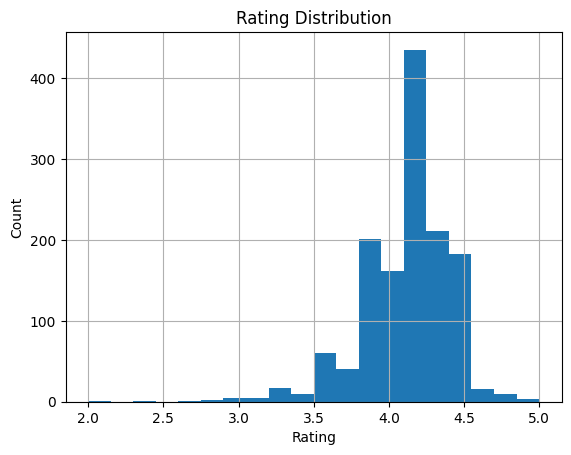

In [24]:
import matplotlib.pyplot as plt

df['rating'].hist(bins=20)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

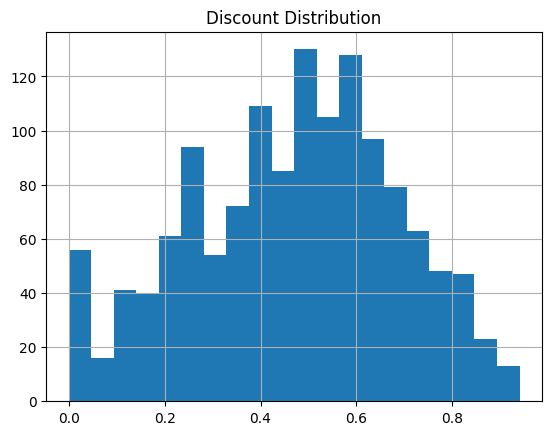

In [25]:
df['discount_percentage'].hist(bins=20)
plt.title("Discount Distribution")
plt.show()

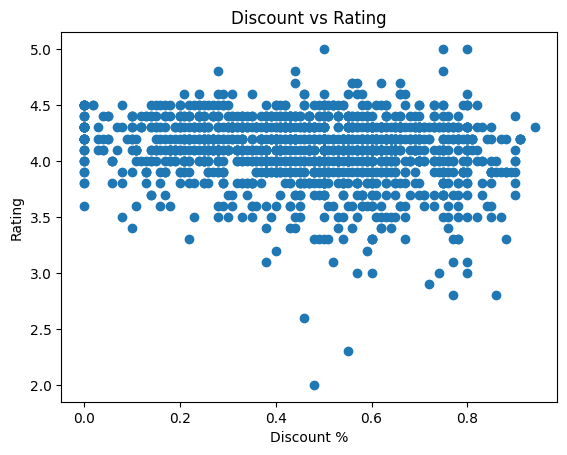

In [26]:
plt.scatter(df['discount_percentage'], df['rating'])
plt.xlabel("Discount %")
plt.ylabel("Rating")
plt.title("Discount vs Rating")
plt.show()

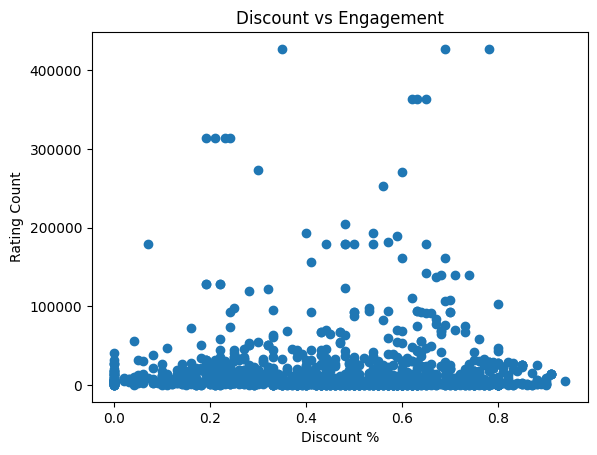

In [27]:
plt.scatter(df['discount_percentage'], df['rating_count'])
plt.xlabel("Discount %")
plt.ylabel("Rating Count")
plt.title("Discount vs Engagement")
plt.show()

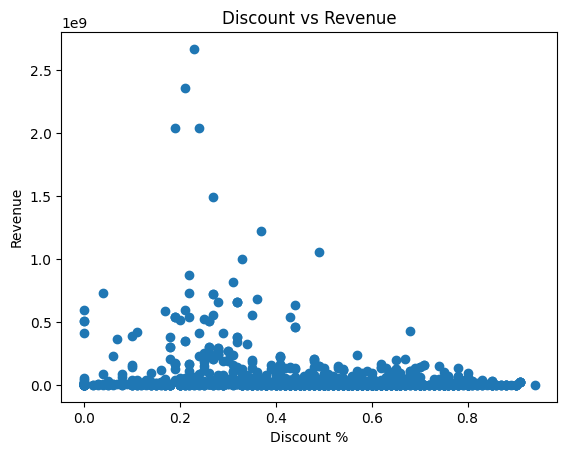

In [28]:
plt.scatter(df['discount_percentage'], df['estimated_revenue'])
plt.xlabel("Discount %")
plt.ylabel("Revenue")
plt.title("Discount vs Revenue")
plt.show()

In [29]:
df.groupby('category')[['discount_percentage','rating','estimated_revenue']].mean()

,discount_percentage,rating,estimated_revenue
category,,,
Car&Motorbike|CarAccessories|InteriorAccessories|AirPurifiers&Ionizers,0.420,3.800000,2.615002e+06
Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters,0.785,4.150000,7.653520e+05
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets,0.350,3.500000,4.687078e+06
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones,0.565,3.600000,7.381788e+06
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers,0.465,4.050000,4.806702e+06
...,...,...,...
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|GelInkRollerballPens",0.000,4.250000,4.733000e+05
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|LiquidInkRollerballPens",0.050,4.150000,6.834150e+05
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|RetractableBallpointPens",0.175,4.300000,1.590610e+06


In [30]:
df.groupby('discount_category')['estimated_revenue'].mean()

discount_category
Low Discount    5.106286e+07
Name: estimated_revenue, dtype: float64

In [31]:
df.groupby('rating_category')['discount_percentage'].mean()/

SyntaxError: invalid syntax (2314972649.py, line 1)

In [32]:
df.groupby('rating_category')['discount_percentage'].mean()

rating_category
High      0.445764
Low       0.480000
Medium    0.507575
Name: discount_percentage, dtype: float64

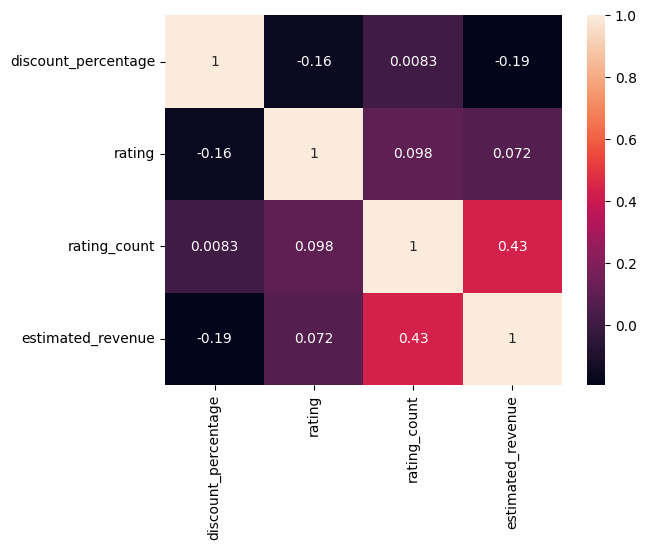

In [33]:
import seaborn as sns

corr = df[['discount_percentage','rating','rating_count','estimated_revenue']].corr()
sns.heatmap(corr, annot=True)
plt.show()